In [46]:
from pybird_w0wa.greenfunction import GreenFunction
from pybird_master.greenfunction import GreenFunction as ana_GreenFunction
import numpy as np 
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 4 
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.labelsize'] = 40
plt.rcParams['xtick.labelsize'] =30 
plt.rcParams['ytick.labelsize'] =30
mpl.rcParams['legend.fontsize'] = 30
mpl.rcParams['axes.titlesize'] = 50
mpl.rcParams['figure.titlesize'] = 50


In [47]:
# ww = [-1.1,-1.]
# wwa = [0.,0.]
ww = [-1.1,-0.9]
wwa = [0.,0.]
quint = [True,False]

x = np.linspace(-10,0,500)
a = np.exp(x)

H0 = 67
Omega0_m = 0.3
res = {}
for i in range(len(ww)):
    w0 = ww[i]
    wa = wwa[i]
    for j in range(len(quint)):
        quintessence = quint[j]
        anaGF = ana_GreenFunction(Omega0_m,w=w0,wa=wa,quintessence=quintessence)

        numGF = GreenFunction(Omega0_m,w=w0,wa=wa,quintessence=quintessence)

        name = 'w0={},wa={},quin={}'.format(w0,wa,quintessence)
        res[name]={'num':np.stack([numGF.D(x),numGF.DD(x),numGF.Dminus(x),numGF.DDminus(x)]),
                   'ana':np.stack([[anaGF.D(ai) for ai in a],
                                   [anaGF.DD(ai) for ai in a],
                                   [anaGF.Dminus(ai) for ai in a],
                                   [anaGF.DDminus(ai) for ai in a]]
                                   )}
        


w0=-1.1,wa=0.0,quin=True
w0=-1.1,wa=0.0,quin=False
w0=-0.9,wa=0.0,quin=True
w0=-0.9,wa=0.0,quin=False


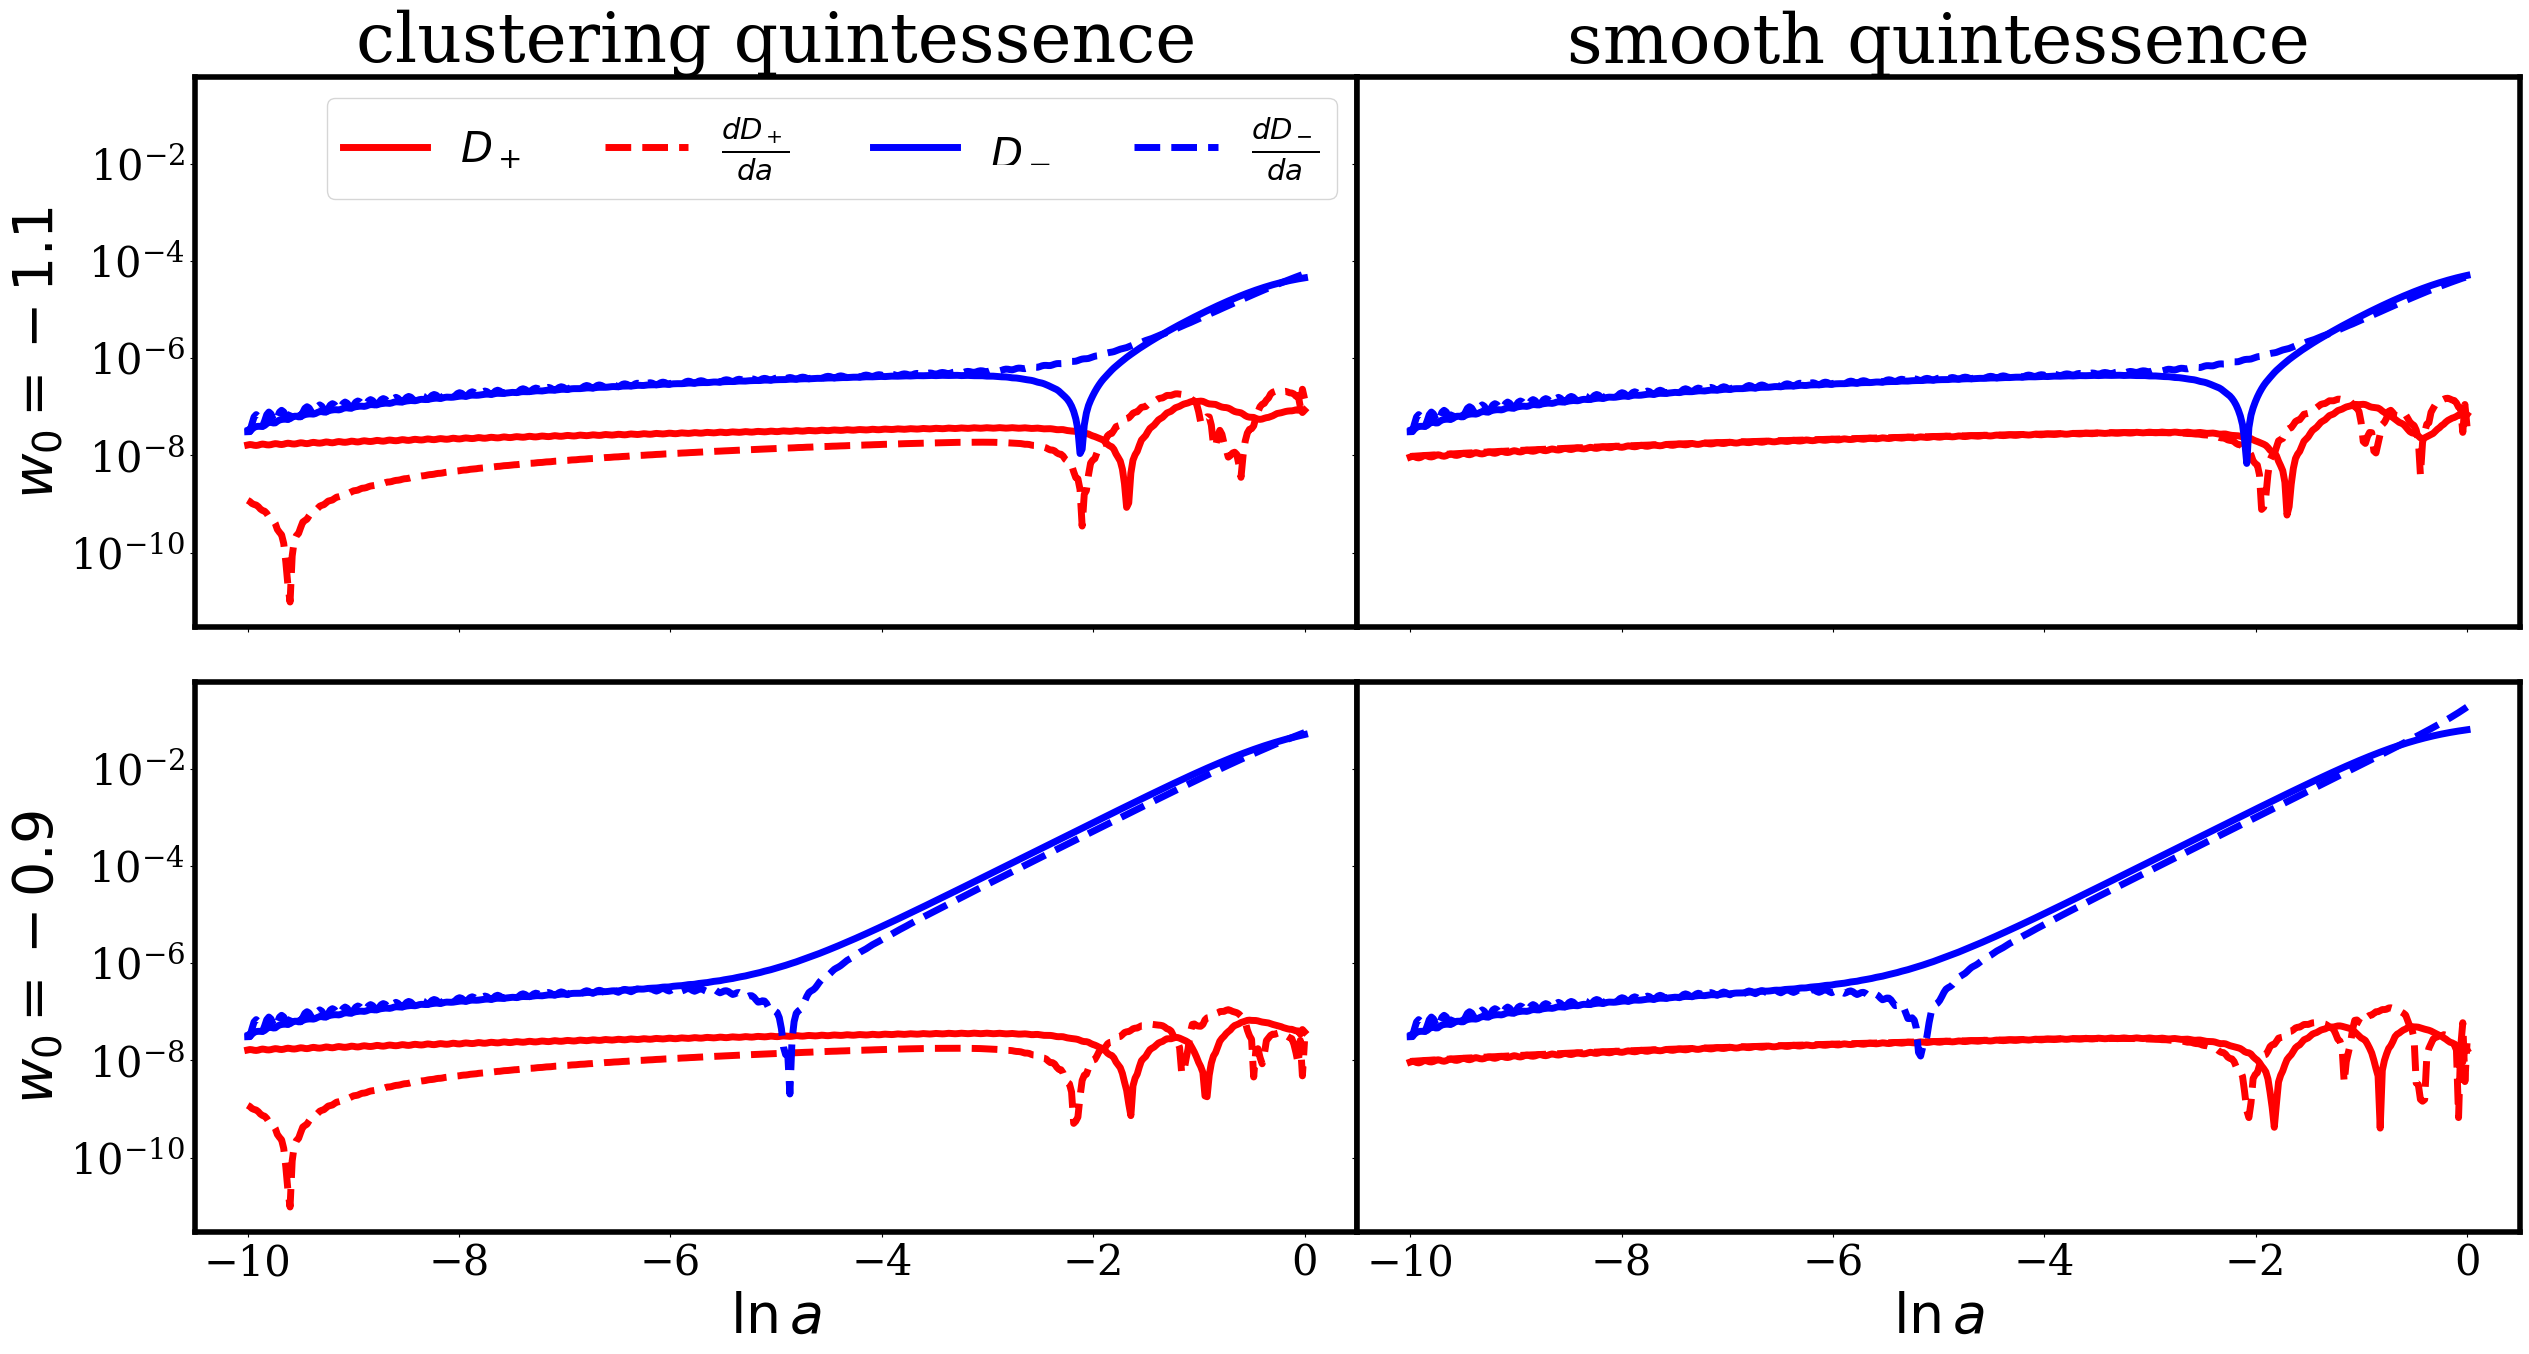

In [51]:
f,ax = plt.subplots(2,2,figsize=(30,15),sharex=True,sharey=True)
f.subplots_adjust(hspace=0.1,wspace=0)

for i in range(len(ww)):
    w0 = ww[i]
    wa = wwa[i]
    for j in range(len(quint)):
        quintessence = quint[j]
        name = 'w0={},wa={},quin={}'.format(w0,wa,quintessence)
        print(name)
        numsol = res[name]['num']
        anasol = res[name]['ana']
    
    
        ax[i][j].plot(x,abs(numsol[0]/anasol[0]-1),color='r',linestyle = '-',label=r'$D_+$',lw=5)
        ax[i][j].plot(x,abs(numsol[1]/anasol[1]-1),color='r',linestyle = '--',label=r'$\frac{dD_+}{da}$',lw=5)
    
        ax[i][j].plot(x,abs(numsol[2]/anasol[2]-1),color='b',linestyle = '-',label=r'$D_-$',lw=5)
        ax[i][j].plot(x,abs(numsol[3]/anasol[3]-1),color='b',linestyle = '--',label=r'$\frac{dD_-}{da}$',lw=5)

    #ax[i][0].set_ylabel(r'$w_0={{}},w_a={{}}$'.format(w0,wa))
    #ax[i][0].set_ylabel(rf'$w_0={w0}, w_a={wa}$')
    ax[i][0].set_ylabel(rf'$w_0={w0}$')
    

    # ax[0].set_title('{}'.format(correct[0]))
    # ax[1].set_title('{}'.format(correct[1]))
    
    # ax[0].semilogy()
    # ax[1].semilogy()
    # ax[0].legend()
    # ax[1].legend()
    # #ax[0].set_ylim(10**-6,10**0)
    # f.suptitle('numerical/analytical-1: w0={},wa={},quintessence={}'.format(w0,wa,quintessence))
    
ax[0][0].legend(ncol=4)
ax[0][0].semilogy()
# ax[0][0].set_title('quintessence={}'.format(quint[0]))
# ax[0][1].set_title('quintessence={}'.format(quint[1]))
ax[0][0].set_title('clustering quintessence')
ax[0][1].set_title('smooth quintessence')
#ax[0][0].set_ylim(10**-9,10**0)
#plt.savefig('compare numerical with analytical.pdf',dpi=300)
# ax[1][0].axhline(10**-2)
# ax[1][1].axhline(10**-2)
# ax[2][1].axhline(10**-2)
# ax[2][1].axhline(10**-1)


ax[1][0].set_xlabel(r'$\ln a$')
ax[1][1].set_xlabel(r'$\ln a$')

#f.suptitle('Numerical/Analytical-1')
plt.savefig('compare numerical with analytical D.pdf',dpi=300)

The initial time matters. If set initial time xini=15, the LCDM and WCDM plots shows large error at low redshift, which couldn't be tolerate since the analytical solution is exact. Thus we can't have any earlier initial time but set it to make sure the error in LCDM and WCDM are well controlled. Thus the most important figures are the first row and second coloum.

If we use the Eds initial condition, the results are good for w<=-1, but for w=-0.3, it is bad. Because, w=-0.3, the DE will be more close to DM and the initial condition doesn't that suitable.

We set initial time no ealier than x=-12 and the valid range for DE is w(xini)<-0.87; thus the error for decay mode is well controlled, no larger than 10%

### more plot

In [4]:
# ww = [-0.4]
# wwa = [-0.8]
# correct_ab = [False,True,True]

# x = np.linspace(-10,0,100)

# H0 = 67
# Omega0_m = 0.3
# res = {}
# for i in range(len(ww)):
#     w0 = ww[i]
#     wa = wwa[i]
#     for j in range(len(correct_ab)):
#         if j == 2:
#             quintessence = True
#         else:
#             quintessence = False
#         anaGF = ana_GreenFunction(Omega0_m,w0=w0,wa=wa,quintessence=quintessence,correct_ab=correct_ab[j])

#         # if j!=0:
#         numGF = GreenFunction(Omega0_m,w0=w0,wa=wa,quintessence=quintessence)

#         name = 'w0={},wa={},coab={},quin={}'.format(w0,wa,correct_ab[j],quintessence)
#         res[name]={'num':np.stack([numGF.D(x),numGF.DD(x),numGF.Dminus(x),numGF.DDminus(x)]),
#                    'ana':np.stack([anaGF.D(x),anaGF.DD(x),anaGF.Dminus(x),anaGF.DDminus(x)])}
        


In [5]:
# f,ax = plt.subplots(4,3,figsize=(20,10),sharex=True,sharey=True)
# f.subplots_adjust(hspace=0.1,wspace=0)

# for i in range(len(ww)):
#     w0 = ww[i]
#     wa = wwa[i]
#     for j in range(len(correct_ab)):
#         if j == 2:
#             quintessence = True
#         else:
#             quintessence = False
#         name = 'w0={},wa={},coab={},quin={}'.format(w0,wa,correct_ab[j],quintessence)

#         numsol = res[name]['num']
#         anasol = res[name]['ana']
    
    
#         ax[i][j].plot(x,abs(numsol[0]/anasol[0]-1),linestyle = '-',label='D+')
#         ax[i][j].plot(x,abs(numsol[1]/anasol[1]-1),linestyle = '--',label='DD+')
    
#         ax[i][j].plot(x,abs(numsol[2]/anasol[2]-1),linestyle = '-.',label='D-')
#         ax[i][j].plot(x,abs(numsol[3]/anasol[3]-1),linestyle = ':',label='DD-')

#     ax[i][0].set_ylabel('w0={},wa={}'.format(w0,wa))
    

#     # ax[0].set_title('{}'.format(correct[0]))
#     # ax[1].set_title('{}'.format(correct[1]))
    
#     # ax[0].semilogy()
#     # ax[1].semilogy()
#     # ax[0].legend()
#     # ax[1].legend()
#     # #ax[0].set_ylim(10**-6,10**0)
#     # f.suptitle('numerical/analytical-1: w0={},wa={},quintessence={}'.format(w0,wa,quintessence))
    
# ax[0][0].legend()
# ax[0][0].semilogy()
# ax[0][0].set_title('correct_ab={},quintessence=False'.format(correct_ab[0]))
# ax[0][1].set_title('correct_ab={},quintessence=False'.format(correct_ab[1]))
# ax[0][2].set_title('correct_ab={},quintessence=True'.format(correct_ab[2]))
# ax[0][0].set_ylim(10**-6,10**0)
# #plt.savefig('compare numerical with analytical.pdf',dpi=300)


In [6]:
np.exp(-20)/(10**-8)

0.2061153622438558

In [7]:
np.exp(-8)

0.00033546262790251185